# Experiment Ladder: Nonlinear Eigenvalue-Warp Misspecification

This notebook studies controlled forms of spectral-operator misspecification. Data are generated from a fixed true graph Laplacian

$$
L_0=

U_0
\operatorname{diag}
\left(
\lambda_1,\ldots,\lambda_n
\right)
U_0^\top,
$$

using a true Leroux covariance spectrum.

Each warped operator preserves the true eigenvectors,

$$
U_{\mathrm{warp}} = U_0,
$$

but replaces the true eigenvalues $\lambda_i$ with warped values

$$
\mu_i = g(\lambda_i).
$$

Therefore, the true covariance remains diagonal in the fitted operator basis. These experiments isolate **eigenvalue misspecification** from eigenvector misspecification and create settings in which the error is theoretically absorbable by a sufficiently flexible spectral filter.

Select one warp in the configuration cell by commenting and uncommenting the corresponding line:

```python
WARP_TYPE = "smooth_quadratic"
# WARP_TYPE = "low_frequency_power"
# WARP_TYPE = "smooth_log_low_frequency"
```

The notebook contains the following nonlinear transformations.

## 1. Smooth quadratic warp

$$
\mu=

g_\delta(\lambda)

\lambda
+
\delta
\frac{\lambda^2}{\lambda_{\max}},
\qquad
\delta \geq 0.
$$

This transformation leaves the zero mode unchanged and progressively stretches middle and high frequencies:

$$
g_\delta(0) = 0,
$$

and

$$
\frac{\mu}{\lambda}=

1
+
\delta
\frac{\lambda}{\lambda_{\max}}.
$$

The distortion is mild near zero and increases toward the largest eigenvalues.

## 2. Low-frequency power warp

$$
\mu=

g_\gamma(\lambda)

\lambda_{\max}
\left(
\frac{\lambda}{\lambda_{\max}}
\right)^\gamma,
\qquad
0 < \gamma \leq 1.
$$

When

$$
\gamma = 1,
$$

there is no distortion. For

$$
\gamma < 1,
$$

the smallest positive eigenvalues are expanded most strongly.

This creates a strong low-frequency perturbation, although the derivative becomes very large near zero when $\gamma < 1$.

## 3. Smooth logarithmic low-frequency warp

$$
\mu=

g_\kappa(\lambda)=

\lambda_{\max}
\frac{
\log\left(
1+\kappa\lambda/\lambda_{\max}
\right)
}{
\log(1+\kappa)
},
\qquad
\kappa \geq 0.
$$

This transformation fixes both endpoints:

$$
g_\kappa(0) = 0,
\qquad
g_\kappa(\lambda_{\max}) = \lambda_{\max},
$$

while smoothly expanding the low-frequency eigenvalues.

Its relative expansion factor is largest near zero and decreases toward one as $\lambda$ approaches $\lambda_{\max}$. This warp is intended to create stronger low-frequency misspecification while remaining smooth and monotone.

The inverse transformation is

$$
g_\kappa^{-1}(\mu)=

\frac{\lambda_{\max}}{\kappa}
\left[
(1+\kappa)^{\mu/\lambda_{\max}}-

1
\right].
$$

Consequently, the true precision expressed as a function of the supplied warped eigenvalue is nonlinear and approximately exponential, which cannot be represented exactly by the affine precision structure of Leroux.

## Data-generating model

Data are always generated using the true eigenvalues $\lambda_i$ and the true Leroux covariance spectrum

$$
F_0(\lambda)=

\frac{\tau_0^2}{
(1-\rho_0)
+
\rho_0\lambda
}.
$$

The warped eigenvalues are used only by the misspecified fitted models. Thus, all models are compared using the same latent field, observations, noise realization, and holdout region.

## Models fitted

Four models are fitted to the same simulated dataset:

1. **Correct-operator Leroux**

   Uses $(U_0,\lambda)$ with the Leroux spectral family.

2. **Correct-operator precision P-spline**

   Uses $(U_0,\lambda)$ with a flexible positive precision spectrum.

3. **Warped-operator Leroux**

   Uses $(U_0,\mu)$ but remains restricted to affine precision in the supplied eigenvalues.

4. **Warped-operator precision P-spline**

   Uses $(U_0,\mu)$ and allows a smooth nonlinear precision correction.

The precision P-spline is constructed so that zero second differences give an exactly affine precision spectrum. Therefore, Leroux-compatible precision is contained as the no-curvature special case, while nonzero second differences allow the model to absorb nonlinear eigenvalue distortion.

## Primary questions

The notebook examines whether:

1. the P-spline behaves similarly to Leroux when the correct operator is supplied;
2. nonlinear eigenvalue warping produces a target precision that cannot be well approximated by an affine Leroux curve;
3. the precision P-spline reduces spectral approximation error under the warped operator; and
4. improved spectral recovery produces more robust held-out spatial prediction.

Because the eigenvectors remain fixed, any remaining failure of the P-spline is attributable to finite-data identification, regularization, optimization, or variational approximation rather than an unrepresentable eigenvector mismatch.

The smooth-log warp is especially useful for the current experiment because it creates substantially stronger low-frequency nonlinear misspecification than the quadratic warp while retaining a valid Laplacian structure in the observed diagnostics.


## 1. Imports

In [55]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt
import torch

from IPython.display import display

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    PositivePrecisionPSplineFullVI,
)

from sdmcar.models_holdout import (
    SpectralCAR_HoldoutVI,
)

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

print("Project root:", ROOT)
print("Device:", DEVICE)

Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu


## 2. Locked configuration

In [56]:
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)

N_ROWS = 15
N_COLS = 15
N = N_ROWS * N_COLS

TAU2_TRUE = 0.70
RHO_TRUE = 0.92
BETA_TRUE = 0.0
SIGMA2_TRUE = 0.15

HOLDOUT_SIDE = 5

# Select exactly one nonlinear warp.
# Comment the active line and uncomment the other line to switch.

# WARP_TYPE = "smooth_quadratic"
# WARP_TYPE = "low_frequency_power"
WARP_TYPE = "smooth_log_low_frequency"

# low-frequency expansion.
SMOOTH_LOG_KAPPA = 10.0

# mu = lambda + delta * lambda^2 / lambda_max
# delta = 0 gives no distortion.
SMOOTH_WARP_DELTA = 1.00

# mu = lambda_max * (lambda / lambda_max)^gamma
# gamma = 1 gives no distortion; gamma < 1 expands low frequencies.
POWER_WARP_GAMMA = 0.40

FIX_SIGMA2 = True
GRAD_CLIP = 10.0
NUM_MC = 8
PRED_MC = 512

LEROUX_ITERS = 1500
LEROUX_LR = 5e-3

PRECISION_SPLINE_ITERS = 5000
PRECISION_SPLINE_LR = 5e-4

PRECISION_SPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 5,

    "prior_std_log_q": 2.0,

    # Was 0.15. Allow more nonlinear curvature.
    "prior_std_d2": 0.30,

    # Slightly more concentrated initial VI distributions.
    "log_std_log_q": -3.0,
    "log_std_d2": -3.0,

    "init_d2": 0.0,

    "log_q_min": -20.0,
    "log_q_max": 20.0,
}

INIT_Q_LEFT = 0.20
INIT_Q_RIGHT = 5.00

print("Nodes:", N)
print("Seed:", SEED)
print("Selected warp:", WARP_TYPE)

if WARP_TYPE == "smooth_quadratic":
    print(
        "Smooth-warp delta:",
        SMOOTH_WARP_DELTA,
    )

elif WARP_TYPE == "low_frequency_power":
    print(
        "Power-warp gamma:",
        POWER_WARP_GAMMA,
    )

elif WARP_TYPE == "smooth_log_low_frequency":
    print(
        "Smooth-log kappa:",
        SMOOTH_LOG_KAPPA,
    )

else:
    raise ValueError(
        "Unknown WARP_TYPE."
    )

Nodes: 225
Seed: 0
Selected warp: smooth_log_low_frequency
Smooth-log kappa: 10.0


## 3. Fixed non-toroidal rook graph

The true adjacency matrix is

$$
W_{0,ij} =
\begin{cases}
1, & \text{if } i \text{ and } j \text{ share a horizontal or vertical boundary}, \\
0, & \text{otherwise}.
\end{cases}
$$

The true combinatorial Laplacian is

$$
L_0 = D_0 - W_0.
$$


In [57]:
def node_index(row, col):
    return row * N_COLS + col


def build_fixed_rook_W():
    W = np.zeros((N, N), dtype=float)

    for row in range(N_ROWS):
        for col in range(N_COLS):
            i = node_index(row, col)

            if col + 1 < N_COLS:
                j = node_index(row, col + 1)
                W[i, j] = 1.0
                W[j, i] = 1.0

            if row + 1 < N_ROWS:
                j = node_index(row + 1, col)
                W[i, j] = 1.0
                W[j, i] = 1.0

    np.fill_diagonal(W, 0.0)
    return W


def graph_laplacian(W):
    degree = W.sum(axis=1)
    L = np.diag(degree) - W
    return 0.5 * (L + L.T)


W_true = build_fixed_rook_W()
L_true = graph_laplacian(W_true)

lam_true, U_true = np.linalg.eigh(L_true)
lam_true = np.clip(lam_true, 0.0, None)

LAM_MAX_TRUE = float(lam_true.max())
positive_mode_mask = lam_true > 1e-8

print("W shape:", W_true.shape)
print("Undirected edges:", np.count_nonzero(W_true) // 2)
print("True eigenvalue range:", (lam_true.min(), lam_true.max()))
print(
    "Smallest positive eigenvalue:",
    lam_true[positive_mode_mask].min(),
)

W shape: (225, 225)
Undirected edges: 420
True eigenvalue range: (np.float64(1.0229233801986029e-15), np.float64(7.912590402935224))
Smallest positive eigenvalue: 0.043704798532387866


## 4. Construct the selected nonlinear warped operator

The notebook defines all three transformations and applies the one selected by `WARP_TYPE`.

### Smooth quadratic warp

$$
\mu
=
\lambda
+
\delta\frac{\lambda^2}{\lambda_{\max}}.
$$

Its inverse is

$$
\lambda
=
\frac{\lambda_{\max}}{2\delta}
\left[
\sqrt{
1+\frac{4\delta\mu}{\lambda_{\max}}
}
-1
\right].
$$

This warp leaves the zero mode unchanged and progressively stretches middle and high frequencies.

### Low-frequency power warp

$$
\mu
=
\lambda_{\max}
\left(
\frac{\lambda}{\lambda_{\max}}
\right)^\gamma.
$$

Its inverse is

$$
\lambda
=
\lambda_{\max}
\left(
\frac{\mu}{\lambda_{\max}}
\right)^{1/\gamma}.
$$

For $\gamma<1$, the smallest positive eigenvalues are expanded most strongly.

### Smooth logarithmic low-frequency warp

$$
\mu
=
\lambda_{\max}
\frac{
\log\left(
1+\kappa\lambda/\lambda_{\max}
\right)
}{
\log(1+\kappa)
}.
$$

Its inverse is

$$
\lambda
=
\frac{\lambda_{\max}}{\kappa}
\left[
(1+\kappa)^{\mu/\lambda_{\max}}
-1
\right].
$$

This warp fixes both endpoints,

$$
g_\kappa(0)=0,
\qquad
g_\kappa(\lambda_{\max})
=
\lambda_{\max},
$$

while smoothly expanding the low-frequency eigenvalues. The relative expansion is largest near zero and decreases toward one as $\lambda$ approaches $\lambda_{\max}$.

For any selected warp, the eigenvectors are retained:

$$
U_{\mathrm{warp}}
=
U_0.
$$

Only the eigenvalues are changed:

$$
\mu_i
=
g(\lambda_i).
$$

The warped operator is therefore constructed as

$$
L_{\mathrm{warp}}
=
U_0
\operatorname{diag}
\left(
\mu_1,\ldots,\mu_n
\right)
U_0^\top.
$$

Because the eigenvectors remain unchanged, the true covariance is still diagonal in the warped basis. The experiment therefore isolates eigenvalue misspecification from eigenvector misspecification.

In [58]:
def smooth_quadratic_eigenvalue_warp(
    lam,
    delta,
    lam_max,
):
    if delta < 0.0:
        raise ValueError(
            "delta must be nonnegative."
        )

    lam = np.asarray(
        lam,
        dtype=float,
    )

    return (
        lam
        + delta * lam**2 / lam_max
    )


def inverse_smooth_quadratic_eigenvalue_warp(
    mu,
    delta,
    lam_max,
):
    if delta < 0.0:
        raise ValueError(
            "delta must be nonnegative."
        )

    mu = np.asarray(
        mu,
        dtype=float,
    )

    if np.isclose(delta, 0.0):
        return mu.copy()

    return (
        lam_max
        / (2.0 * delta)
        * (
            np.sqrt(
                1.0
                + 4.0
                * delta
                * mu
                / lam_max
            )
            - 1.0
        )
    )


def power_eigenvalue_warp(
    lam,
    gamma,
    lam_max,
):
    if gamma <= 0.0:
        raise ValueError(
            "gamma must be positive."
        )

    x = np.clip(
        np.asarray(lam, dtype=float)
        / lam_max,
        0.0,
        1.0,
    )

    return lam_max * x**gamma


def inverse_power_eigenvalue_warp(
    mu,
    gamma,
    lam_max,
):
    if gamma <= 0.0:
        raise ValueError(
            "gamma must be positive."
        )

    x = np.clip(
        np.asarray(mu, dtype=float)
        / lam_max,
        0.0,
        1.0,
    )

    return lam_max * x**(
        1.0 / gamma
    )


def smooth_log_eigenvalue_warp(
    lam,
    kappa,
    lam_max,
):
    """
    Smooth logarithmic low-frequency expansion:

        mu = lam_max
             * log(1 + kappa * lam / lam_max)
             / log(1 + kappa)

    kappa = 0 gives the identity.
    """
    if kappa < 0.0:
        raise ValueError(
            "kappa must be nonnegative."
        )

    lam = np.asarray(
        lam,
        dtype=float,
    )

    if np.isclose(kappa, 0.0):
        return lam.copy()

    x = np.clip(
        lam / lam_max,
        0.0,
        1.0,
    )

    return (
        lam_max
        * np.log1p(kappa * x)
        / np.log1p(kappa)
    )


def inverse_smooth_log_eigenvalue_warp(
    mu,
    kappa,
    lam_max,
):
    """
    Inverse of the smooth logarithmic warp:

        lam = lam_max / kappa
              * [
                  (1 + kappa)^(mu / lam_max)
                  - 1
                ].
    """
    if kappa < 0.0:
        raise ValueError(
            "kappa must be nonnegative."
        )

    mu = np.asarray(
        mu,
        dtype=float,
    )

    if np.isclose(kappa, 0.0):
        return mu.copy()

    scaled_mu = np.clip(
        mu / lam_max,
        0.0,
        1.0,
    )

    return (
        lam_max
        / kappa
        * np.expm1(
            np.log1p(kappa)
            * scaled_mu
        )
    )

if WARP_TYPE == "smooth_quadratic":
    lam_warp = (
        smooth_quadratic_eigenvalue_warp(
            lam=lam_true,
            delta=SMOOTH_WARP_DELTA,
            lam_max=LAM_MAX_TRUE,
        )
    )

    WARP_OPERATOR_NAME = (
        "smooth_quadratic_warp"
    )
    WARP_DISPLAY_NAME = (
        "Smooth-quadratic-warped"
    )
    WARP_DISPLAY_LABEL = (
        rf"Smooth quadratic, "
        rf"$\delta={SMOOTH_WARP_DELTA}$"
    )
    WARP_PARAMETER_NAME = "delta"
    WARP_PARAMETER_VALUE = (
        SMOOTH_WARP_DELTA
    )
    WARP_DISTORTION_TITLE = (
        "Distortion increases with frequency"
    )

    def inverse_selected_eigenvalue_warp(mu):
        return (
            inverse_smooth_quadratic_eigenvalue_warp(
                mu=mu,
                delta=SMOOTH_WARP_DELTA,
                lam_max=LAM_MAX_TRUE,
            )
        )

elif WARP_TYPE == "low_frequency_power":
    lam_warp = power_eigenvalue_warp(
        lam=lam_true,
        gamma=POWER_WARP_GAMMA,
        lam_max=LAM_MAX_TRUE,
    )

    WARP_OPERATOR_NAME = (
        "low_frequency_power_warp"
    )
    WARP_DISPLAY_NAME = (
        "Low-frequency-power-warped"
    )
    WARP_DISPLAY_LABEL = (
        rf"Power warp, "
        rf"$\gamma={POWER_WARP_GAMMA}$"
    )
    WARP_PARAMETER_NAME = "gamma"
    WARP_PARAMETER_VALUE = (
        POWER_WARP_GAMMA
    )
    WARP_DISTORTION_TITLE = (
        "Distortion is strongest at low frequencies"
    )

    def inverse_selected_eigenvalue_warp(mu):
        return (
            inverse_power_eigenvalue_warp(
                mu=mu,
                gamma=POWER_WARP_GAMMA,
                lam_max=LAM_MAX_TRUE,
            )
        )

elif WARP_TYPE == "smooth_log_low_frequency":
    lam_warp = (
        smooth_log_eigenvalue_warp(
            lam=lam_true,
            kappa=SMOOTH_LOG_KAPPA,
            lam_max=LAM_MAX_TRUE,
        )
    )

    WARP_OPERATOR_NAME = (
        "smooth_log_low_frequency_warp"
    )

    WARP_DISPLAY_NAME = (
        "Smooth-log-low-frequency-warped"
    )

    WARP_DISPLAY_LABEL = (
        rf"Smooth log warp, "
        rf"$\kappa={SMOOTH_LOG_KAPPA}$"
    )

    WARP_PARAMETER_NAME = "kappa"

    WARP_PARAMETER_VALUE = (
        SMOOTH_LOG_KAPPA
    )

    WARP_DISTORTION_TITLE = (
        "Smooth expansion concentrated "
        "at low frequencies"
    )

    def inverse_selected_eigenvalue_warp(mu):
        return (
            inverse_smooth_log_eigenvalue_warp(
                mu=mu,
                kappa=SMOOTH_LOG_KAPPA,
                lam_max=LAM_MAX_TRUE,
            )
        )

else:
    raise ValueError(
        "Unknown WARP_TYPE."
    )


U_warp = U_true.copy()

L_warp = (
    U_warp
    @ np.diag(lam_warp)
    @ U_warp.T
)

L_warp = 0.5 * (
    L_warp + L_warp.T
)

positive_warp_mask = (
    lam_warp > 1e-8
)

print("Selected warp:", WARP_TYPE)
print(
    "Warp parameter:",
    WARP_PARAMETER_NAME,
    "=",
    WARP_PARAMETER_VALUE,
)
print(
    "Warped eigenvalue range:",
    (
        lam_warp.min(),
        lam_warp.max(),
    ),
)
print(
    "Warped smallest positive eigenvalue:",
    lam_warp[positive_warp_mask].min(),
)
print(
    "Smallest-positive-mode expansion factor:",
    (
        lam_warp[positive_mode_mask].min()
        / lam_true[positive_mode_mask].min()
    ),
)
print(
    "Maximum-eigenvalue expansion factor:",
    (
        lam_warp.max()
        / lam_true.max()
    ),
)

Selected warp: smooth_log_low_frequency
Warp parameter: kappa = 10.0
Warped eigenvalue range: (np.float64(4.265921834879966e-15), np.float64(7.912590402935224))
Warped smallest positive eigenvalue: 0.1774075574511325
Smallest-positive-mode expansion factor: 4.059223778818312
Maximum-eigenvalue expansion factor: 1.0


### Operator validation

In [59]:
eigenpair_error = (
    np.linalg.norm(
        L_warp @ U_warp
        - U_warp * lam_warp[None, :],
        ord="fro",
    )
    / np.linalg.norm(L_warp, ord="fro")
)

commutator = (
    L_true @ L_warp
    - L_warp @ L_true
)

commutator_ratio = (
    np.linalg.norm(commutator, ord="fro")
    / (
        np.linalg.norm(L_true, ord="fro")
        * np.linalg.norm(L_warp, ord="fro")
    )
)

row_sum_error = np.max(
    np.abs(
        L_warp.sum(axis=1)
    )
)

minimum_warped_eigenvalue = float(
    np.linalg.eigvalsh(L_warp).min()
)

off_diagonal_entries = L_warp[
    ~np.eye(N, dtype=bool)
]

positive_off_diagonal_fraction = float(
    np.mean(
        off_diagonal_entries > 1e-10
    )
)

print("Eigenpair error:", eigenpair_error)
print("Normalized commutator:", commutator_ratio)
print("Maximum absolute row sum:", row_sum_error)
print("Minimum warped eigenvalue:", minimum_warped_eigenvalue)
print(
    "Fraction of positive off-diagonal entries:",
    positive_off_diagonal_fraction,
)

Eigenpair error: 1.7119901844493416e-15
Normalized commutator: 6.337348142147181e-17
Maximum absolute row sum: 2.3675506000131463e-14
Minimum warped eigenvalue: 4.028027911218146e-15
Fraction of positive off-diagonal entries: 0.0


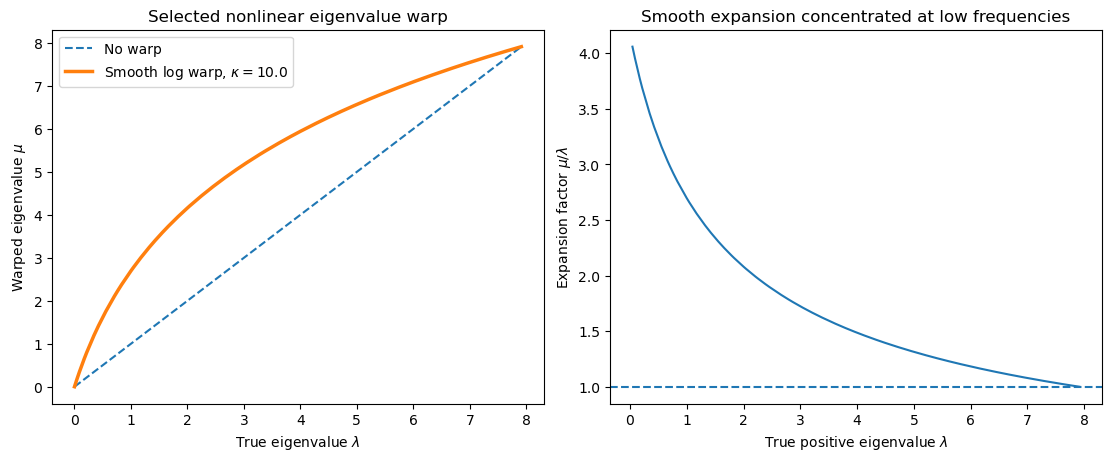

In [60]:
order_true = np.argsort(
    lam_true
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    constrained_layout=True,
)

axes[0].plot(
    lam_true[order_true],
    lam_true[order_true],
    linestyle="--",
    label="No warp",
)

axes[0].plot(
    lam_true[order_true],
    lam_warp[order_true],
    linewidth=2.5,
    label=WARP_DISPLAY_LABEL,
)

axes[0].set_xlabel(
    r"True eigenvalue $\lambda$"
)
axes[0].set_ylabel(
    r"Warped eigenvalue $\mu$"
)
axes[0].set_title(
    "Selected nonlinear eigenvalue warp"
)
axes[0].legend()

relative_change = np.ones_like(
    lam_true
)

relative_change[
    positive_mode_mask
] = (
    lam_warp[positive_mode_mask]
    / lam_true[positive_mode_mask]
)

axes[1].plot(
    lam_true[positive_mode_mask],
    relative_change[
        positive_mode_mask
    ],
)

axes[1].axhline(
    1.0,
    linestyle="--",
)

axes[1].set_xlabel(
    r"True positive eigenvalue $\lambda$"
)
axes[1].set_ylabel(
    r"Expansion factor $\mu/\lambda$"
)
axes[1].set_title(
    WARP_DISTORTION_TITLE
)

plt.show()

## 5. Simulate one true Leroux spatial field

The true covariance spectrum is

$$
F_0(\lambda)=

\frac{\tau_0^2}
{(1-\rho_0)+\rho_0\lambda}.
$$

The latent spatial field is

$$
\phi_0=

U_0
\operatorname{diag}
\left(
\sqrt{F_0(\lambda_i)}
\right)
z,
\qquad
z \sim N(0,I).
$$

The observed response is

$$
y
=

\beta_0 \mathbf{1}
+
\phi_0
+
\varepsilon,
\qquad
\varepsilon
\sim
N(0,\sigma_0^2 I).
$$


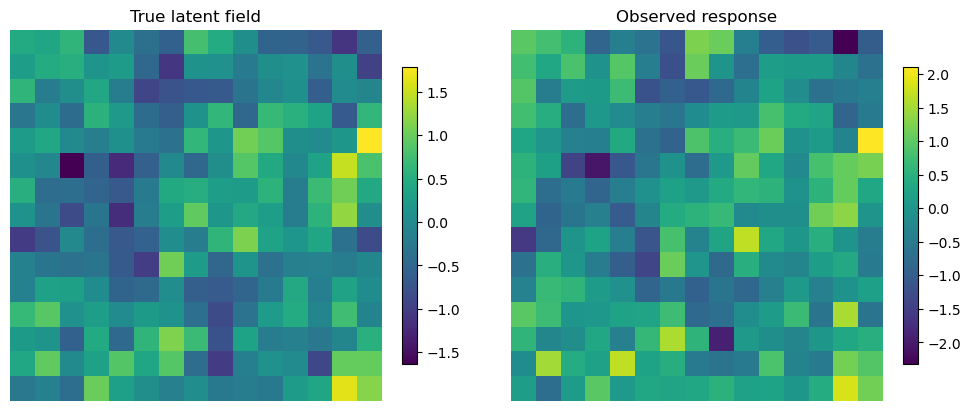

In [61]:
rng = np.random.default_rng(SEED)

F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = (
    U_true
    @ (
        np.sqrt(F_true)
        * rng.normal(size=N)
    )
)

eta_true = BETA_TRUE + phi_true

y = (
    eta_true
    + rng.normal(
        loc=0.0,
        scale=np.sqrt(SIGMA2_TRUE),
        size=N,
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

image_0 = axes[0].imshow(
    eta_true.reshape(N_ROWS, N_COLS)
)
axes[0].set_title("True latent field")
axes[0].axis("off")
fig.colorbar(image_0, ax=axes[0], shrink=0.8)

image_1 = axes[1].imshow(
    y.reshape(N_ROWS, N_COLS)
)
axes[1].set_title("Observed response")
axes[1].axis("off")
fig.colorbar(image_1, ax=axes[1], shrink=0.8)

plt.show()

## 6. Holdout block and PyTorch tensors

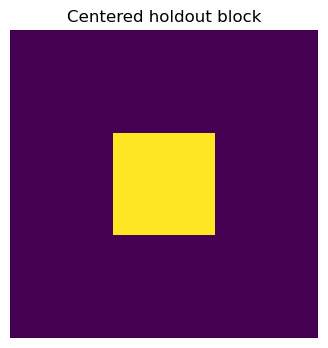

Training nodes: 200
Held-out nodes: 25


In [62]:
def centered_block_mask(side):
    mask = np.zeros(
        (N_ROWS, N_COLS),
        dtype=bool,
    )

    row_start = (N_ROWS - side) // 2
    col_start = (N_COLS - side) // 2

    mask[
        row_start:row_start + side,
        col_start:col_start + side,
    ] = True

    return mask.ravel()


def graph_tensors(lam, U):
    return (
        torch.tensor(
            np.clip(lam, 0.0, None),
            dtype=torch.double,
            device=DEVICE,
        ),
        torch.tensor(
            U,
            dtype=torch.double,
            device=DEVICE,
        ),
    )


test_mask = centered_block_mask(HOLDOUT_SIDE)
train_mask = ~test_mask

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=DEVICE,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

y_test_t = y_all_t[is_holdout_t].clone()

y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = (
    10.0
    * torch.eye(
        1,
        dtype=torch.double,
        device=DEVICE,
    )
)

lam_true_t, U_true_t = graph_tensors(
    lam_true,
    U_true,
)

lam_warp_t, U_warp_t = graph_tensors(
    lam_warp,
    U_warp,
)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(test_mask.reshape(N_ROWS, N_COLS))
ax.set_title("Centered holdout block")
ax.axis("off")
plt.show()

print("Training nodes:", int(train_mask.sum()))
print("Held-out nodes:", int(test_mask.sum()))

## 7. Filter factories

In [63]:
def rho_to_raw(rho, rho_eps=1e-4):
    probability = rho / (1.0 - rho_eps)

    if not 0.0 < probability < 1.0:
        raise ValueError(
            "rho is incompatible with rho_eps."
        )

    return math.log(
        probability
        / (1.0 - probability)
    )


def make_leroux_filter():
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(TAU2_TRUE),
        log_std_log_tau2=-2.3,
        mu_rho_raw=rho_to_raw(RHO_TRUE),
        log_std_rho_raw=-2.3,
        fixed_rho=None,
        rho_eps=1e-4,
    ).to(DEVICE)


def make_precision_spline_filter(lam_t):
    return PositivePrecisionPSplineFullVI(
        lam_max=float(lam_t.max().item()),
        mu_log_q_left=math.log(INIT_Q_LEFT),
        mu_log_q_right=math.log(INIT_Q_RIGHT),
        **PRECISION_SPLINE_KWARGS,
    ).to(DEVICE)

## 8. Shared VI fitting helper

In [64]:
def fit_spectral_model(
    *,
    label,
    operator,
    lam_t,
    U_t,
    filter_module,
    iterations,
    learning_rate,
    seed,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=(
            SIGMA2_TRUE
            if FIX_SIGMA2
            else None
        ),
        jitter=1e-8,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    history = []

    for iteration in range(iterations):
        optimizer.zero_grad()

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"{label}: non-finite loss "
                f"at iteration {iteration + 1}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        optimizer.step()

        history.append(
            float(elbo.detach().cpu())
        )

        if (iteration + 1) % 250 == 0:
            recent_elbo = float(
                np.mean(history[-50:])
            )

            print(
                f"{label}: "
                f"{iteration + 1}/{iterations}, "
                f"ELBO={history[-1]:.3f}, "
                f"recent={recent_elbo:.3f}"
            )

    torch.manual_seed(seed + 10_000)

    prediction = model.predict_vi_mc(
        num_mc=PRED_MC,
    )

    metrics = model.score_predictions(
        y_test=y_test_t,
        prediction=prediction,
    )

    return {
        "label": label,
        "operator": operator,
        "model": model,
        "prediction": prediction,
        "metrics": metrics,
        "history": history,
        "lam_t": lam_t,
        "U_t": U_t,
    }

## 9. Fit correct and selected-warp models

In [65]:
correct_leroux = fit_spectral_model(
    label="Correct-W Leroux",
    operator="correct",
    lam_t=lam_true_t,
    U_t=U_true_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

correct_spline = fit_spectral_model(
    label="Correct-W precision P-spline",
    operator="correct",
    lam_t=lam_true_t,
    U_t=U_true_t,
    filter_module=make_precision_spline_filter(
        lam_true_t
    ),
    iterations=PRECISION_SPLINE_ITERS,
    learning_rate=PRECISION_SPLINE_LR,
    seed=SEED,
)

warped_leroux = fit_spectral_model(
    label=f"{WARP_DISPLAY_NAME} Leroux",
    operator=WARP_OPERATOR_NAME,
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

warped_spline = fit_spectral_model(
    label=(
        f"{WARP_DISPLAY_NAME} "
        f"precision P-spline"
    ),
    operator=WARP_OPERATOR_NAME,
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    filter_module=make_precision_spline_filter(
        lam_warp_t
    ),
    iterations=PRECISION_SPLINE_ITERS,
    learning_rate=PRECISION_SPLINE_LR,
    seed=SEED,
)

all_fits = [
    correct_leroux,
    correct_spline,
    warped_leroux,
    warped_spline,
]

Correct-W Leroux: 250/1500, ELBO=-21.000, recent=-20.948
Correct-W Leroux: 500/1500, ELBO=-20.015, recent=-20.433
Correct-W Leroux: 750/1500, ELBO=-20.116, recent=-20.581
Correct-W Leroux: 1000/1500, ELBO=-20.391, recent=-20.426
Correct-W Leroux: 1250/1500, ELBO=-21.242, recent=-20.557
Correct-W Leroux: 1500/1500, ELBO=-20.539, recent=-20.439
Correct-W precision P-spline: 250/5000, ELBO=-32.373, recent=-32.580
Correct-W precision P-spline: 500/5000, ELBO=-31.603, recent=-31.167
Correct-W precision P-spline: 750/5000, ELBO=-29.811, recent=-30.137
Correct-W precision P-spline: 1000/5000, ELBO=-29.065, recent=-29.330
Correct-W precision P-spline: 1250/5000, ELBO=-29.499, recent=-28.765
Correct-W precision P-spline: 1500/5000, ELBO=-28.805, recent=-28.352
Correct-W precision P-spline: 1750/5000, ELBO=-27.780, recent=-27.825
Correct-W precision P-spline: 2000/5000, ELBO=-26.981, recent=-27.260
Correct-W precision P-spline: 2250/5000, ELBO=-26.866, recent=-26.960
Correct-W precision P-spline

## 10. Predictive comparison

In [66]:
def summarize_prediction(result):
    pred_mean = (
        result["prediction"]["mean"]
        .detach()
        .cpu()
        .numpy()
    )

    eta_rmse = float(
        np.sqrt(
            np.mean(
                (
                    pred_mean
                    - eta_true[test_mask]
                ) ** 2
            )
        )
    )

    is_correct = (
        result["operator"] == "correct"
    )

    return {
        "model": result["label"],
        "operator": result["operator"],
        "warp_type": (
            "correct"
            if is_correct
            else WARP_TYPE
        ),
        "warp_parameter_name": (
            None
            if is_correct
            else WARP_PARAMETER_NAME
        ),
        "warp_parameter_value": (
            np.nan
            if is_correct
            else WARP_PARAMETER_VALUE
        ),
        "test_y_rmse": float(
            result["metrics"]["rmse"]
        ),
        "test_y_mae": float(
            result["metrics"]["mae"]
        ),
        "test_eta_rmse": eta_rmse,
    }


prediction_results = pd.DataFrame(
    [
        summarize_prediction(result)
        for result in all_fits
    ]
)

display(prediction_results)

,model,operator,warp_type,warp_parameter_name,warp_parameter_value,test_y_rmse,test_y_mae,test_eta_rmse
0,Correct-W Leroux,correct,correct,NaN,NaN,0.704957,0.570036,0.583939
1,Correct-W precision P-spline,correct,correct,NaN,NaN,0.715391,0.578058,0.600718
2,Smooth-log-low-frequency-warped Leroux,smooth_log_low_frequency_warp,smooth_log_low_frequency,kappa,10.0,0.707710,0.572466,0.581686
3,Smooth-log-low-frequency-warped precision P-sp...,smooth_log_low_frequency_warp,smooth_log_low_frequency,kappa,10.0,0.703589,0.568427,0.581920


In [67]:
correct_leroux_rmse = prediction_results.loc[
    prediction_results["model"]
    == correct_leroux["label"],
    "test_eta_rmse",
].iloc[0]

correct_spline_rmse = prediction_results.loc[
    prediction_results["model"]
    == correct_spline["label"],
    "test_eta_rmse",
].iloc[0]

warped_leroux_rmse = prediction_results.loc[
    prediction_results["model"]
    == warped_leroux["label"],
    "test_eta_rmse",
].iloc[0]

warped_spline_rmse = prediction_results.loc[
    prediction_results["model"]
    == warped_spline["label"],
    "test_eta_rmse",
].iloc[0]

comparison_results = pd.DataFrame(
    [
        {
            "quantity": "Leroux signed RMSE change",
            "value": (
                warped_leroux_rmse
                - correct_leroux_rmse
            ),
        },
        {
            "quantity": "P-spline signed RMSE change",
            "value": (
                warped_spline_rmse
                - correct_spline_rmse
            ),
        },
        {
            "quantity": "P-spline gain under selected warp",
            "value": (
                warped_leroux_rmse
                - warped_spline_rmse
            ),
        },
        {
            "quantity": "Correct-W P-spline minus Leroux",
            "value": (
                correct_spline_rmse
                - correct_leroux_rmse
            ),
        },
        {
            "quantity": "Warped P-spline minus Leroux",
            "value": (
                warped_spline_rmse
                - warped_leroux_rmse
            ),
        },
    ]
)

display(comparison_results)

,quantity,value
0,Leroux signed RMSE change,-0.002253
1,P-spline signed RMSE change,-0.018799
2,P-spline gain under selected warp,-0.000234
3,Correct-W P-spline minus Leroux,0.016780
4,Warped P-spline minus Leroux,0.000234


## 11. Absorbability and analytic target

For both nonlinear warps,

$$
U_{\mathrm{warp}}=U_0.
$$

Therefore,

$$
U_{\mathrm{warp}}^\top
\Sigma_0
U_{\mathrm{warp}}
$$

is diagonal up to numerical error.

The target spectrum is obtained from the inverse of the selected warp:

$$
F_{\mathrm{target}}(\mu)
=
\frac{\tau_0^2}{
(1-\rho_0)
+
\rho_0 g^{-1}(\mu)
}.
$$

The target precision is

$$
q_{\mathrm{target}}(\mu)
=
\frac{
(1-\rho_0)
+
\rho_0g^{-1}(\mu)
}{
\tau_0^2
}.
$$

This target is nonlinear in the supplied warped eigenvalue $\mu$, whereas Leroux remains restricted to affine precision.

In [68]:
Sigma_true = (
    U_true
    @ np.diag(F_true)
    @ U_true.T
)

Sigma_in_warped_basis = (
    U_warp.T
    @ Sigma_true
    @ U_warp
)

target_spectrum_warp = np.diag(
    Sigma_in_warped_basis
)

off_diagonal = (
    Sigma_in_warped_basis
    - np.diag(target_spectrum_warp)
)

off_diagonal_ratio = (
    np.linalg.norm(
        off_diagonal,
        ord="fro",
    ) ** 2
    / np.linalg.norm(
        Sigma_in_warped_basis,
        ord="fro",
    ) ** 2
)

lam_recovered = (
    inverse_selected_eigenvalue_warp(
        lam_warp
    )
)

target_spectrum_analytic = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_recovered
    )
)

target_precision_warp = (
    1.0 / target_spectrum_warp
)

print(
    "Selected warp:",
    WARP_TYPE,
)
print(
    "Off-diagonal covariance ratio:",
    off_diagonal_ratio,
)
print(
    "Spectrally absorbable proportion:",
    1.0 - off_diagonal_ratio,
)
print(
    "Maximum inverse-warp eigenvalue error:",
    np.max(
        np.abs(
            lam_recovered
            - lam_true
        )
    ),
)
print(
    "Maximum analytic target-spectrum error:",
    np.max(
        np.abs(
            target_spectrum_analytic
            - target_spectrum_warp
        )
    ),
)

Selected warp: smooth_log_low_frequency
Off-diagonal covariance ratio: 5.610162176983066e-30
Spectrally absorbable proportion: 1.0
Maximum inverse-warp eigenvalue error: 4.440892098500626e-15
Maximum analytic target-spectrum error: 2.7533531010703882e-14


### Structural Leroux failure: best affine precision approximation

In [69]:
from scipy.optimize import minimize


mu_positive = lam_warp[
    positive_warp_mask
]

q_target_positive = (
    target_precision_warp[
        positive_warp_mask
    ]
)


def affine_log_precision_loss(
    log_parameters,
):
    """
    Fit a positive affine precision:

        q(mu) = a + b * mu,

    using the same log-scale loss used in the
    reported spectrum RMSE.
    """
    intercept = np.exp(
        log_parameters[0]
    )

    slope = np.exp(
        log_parameters[1]
    )

    q_estimated = (
        intercept
        + slope * mu_positive
    )

    return float(
        np.mean(
            (
                np.log(q_estimated)
                - np.log(q_target_positive)
            ) ** 2
        )
    )


initial_intercept = max(
    float(q_target_positive[0]),
    1e-8,
)

initial_slope = max(
    float(
        (
            q_target_positive[-1]
            - q_target_positive[0]
        )
        / (
            mu_positive[-1]
            - mu_positive[0]
        )
    ),
    1e-8,
)


affine_optimization = minimize(
    affine_log_precision_loss,
    x0=np.log(
        [
            initial_intercept,
            initial_slope,
        ]
    ),
    method="L-BFGS-B",
)


if not affine_optimization.success:
    print(
        "Affine optimization warning:",
        affine_optimization.message,
    )


best_affine_intercept = np.exp(
    affine_optimization.x[0]
)

best_affine_slope = np.exp(
    affine_optimization.x[1]
)


q_best_affine = (
    best_affine_intercept
    + best_affine_slope * lam_warp
)

q_best_affine = np.clip(
    q_best_affine,
    1e-12,
    None,
)

F_best_affine = (
    1.0 / q_best_affine
)


best_affine_positive_log_rmse = float(
    np.sqrt(
        affine_optimization.fun
    )
)


print(
    "Best affine intercept:",
    best_affine_intercept,
)

print(
    "Best affine slope:",
    best_affine_slope,
)

print(
    "Best positive-mode affine "
    "log-spectrum RMSE:",
    best_affine_positive_log_rmse,
)

Best affine intercept: 1.342749033999972e-05
Best affine slope: 0.8427894802315642
Best positive-mode affine log-spectrum RMSE: 0.27301378960231926


In [70]:
@torch.no_grad()
def plugin_covariance_spectrum(result):
    """
    Evaluate the fitted covariance spectrum at the
    posterior mean of the unconstrained parameters.

    This is a single fitted spectrum, not an average
    over posterior draws.
    """
    model = result["model"]

    theta_mean = (
        model.filter.mean_unconstrained()
    )

    F_plugin = model.filter.spectrum(
        result["lam_t"],
        theta_mean,
    )

    return (
        F_plugin
        .detach()
        .cpu()
        .numpy()
    )


# P-spline plugin covariance spectrum
F_warped_spline_plugin = (
    plugin_covariance_spectrum(
        warped_spline
    )
)

# The analytic target covariance spectrum is 1 / precision
F_target_warp = (
    1.0
    / np.clip(
        target_precision_warp,
        1e-12,
        None,
    )
)


# Use positive modes only, matching the affine benchmark
comparison_mask = (
    positive_warp_mask
    & np.isfinite(F_target_warp)
    & np.isfinite(F_warped_spline_plugin)
    & (F_target_warp > 0.0)
    & (F_warped_spline_plugin > 0.0)
)


p_spline_plugin_log_rmse = float(
    np.sqrt(
        np.mean(
            (
                np.log(
                    F_warped_spline_plugin[
                        comparison_mask
                    ]
                )
                - np.log(
                    F_target_warp[
                        comparison_mask
                    ]
                )
            ) ** 2
        )
    )
)


absolute_improvement = (
    best_affine_positive_log_rmse
    - p_spline_plugin_log_rmse
)

relative_improvement_percent = (
    100.0
    * absolute_improvement
    / best_affine_positive_log_rmse
)


print(
    "Best affine positive-mode "
    "log-spectrum RMSE:",
    best_affine_positive_log_rmse,
)

print(
    "P-spline plugin positive-mode "
    "log-spectrum RMSE:",
    p_spline_plugin_log_rmse,
)

print(
    "Absolute RMSE improvement:",
    absolute_improvement,
)

print(
    "Relative RMSE reduction (%):",
    relative_improvement_percent,
)


if p_spline_plugin_log_rmse < (
    best_affine_positive_log_rmse
):
    print(
        "\nResult: the fitted P-spline represents "
        "the warped target better than the best "
        "possible affine precision."
    )
else:
    print(
        "\nResult: the fitted P-spline does not "
        "currently improve on the best affine "
        "precision."
    )

Best affine positive-mode log-spectrum RMSE: 0.27301378960231926
P-spline plugin positive-mode log-spectrum RMSE: 0.11309308053386166
Absolute RMSE improvement: 0.1599207090684576
Relative RMSE reduction (%): 58.576055554337856

Result: the fitted P-spline represents the warped target better than the best possible affine precision.


## 12. Posterior spectrum summaries

These numbers measure the difference between two **different summaries** of the fitted spectrum:

$$
F_{\text{plugin}}(\lambda)=

F\left(\lambda; \mathbb{E}_q[\theta]\right)
$$

versus

$$
F_{\text{post.mean}}(\lambda)=

\mathbb{E}_q\left[F(\lambda;\theta)\right].
$$

Because the spectrum is nonlinear in the parameters,

$$
F\left(\mathbb{E}[\theta]\right)
\neq
\mathbb{E}\left[F(\theta)\right].
$$


In [71]:
@torch.no_grad()
def plugin_spectrum(
    result,
):
    """
    Spectrum evaluated at the variational
    mean of the filter parameters.
    """
    model = result["model"]

    theta_mean = (
        model.filter
        .mean_unconstrained()
    )

    return (
        model.filter
        .spectrum(
            result["lam_t"],
            theta_mean,
        )
        .detach()
        .cpu()
        .numpy()
    )


@torch.no_grad()
def posterior_spectrum_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_000,
):
    """
    Monte Carlo summary of the posterior
    distribution of F(lambda).
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie "
            "between 0 and 1."
        )

    torch.manual_seed(seed)

    model = result["model"]
    spectra = []

    for _ in range(draws):
        theta = (
            model.filter
            .sample_unconstrained()
        )

        spectrum_draw = (
            model.filter
            .spectrum(
                result["lam_t"],
                theta,
            )
        )

        spectra.append(
            spectrum_draw
        )

    spectra = torch.stack(
        spectra,
        dim=0,
    )

    tail = (
        1.0 - credible_level
    ) / 2.0

    posterior_mean = (
        spectra.mean(dim=0)
    )

    posterior_lower = (
        torch.quantile(
            spectra,
            tail,
            dim=0,
        )
    )

    posterior_upper = (
        torch.quantile(
            spectra,
            1.0 - tail,
            dim=0,
        )
    )

    return tuple(
        value
        .detach()
        .cpu()
        .numpy()
        for value in (
            posterior_mean,
            posterior_lower,
            posterior_upper,
        )
    )


# Plugin spectra for structural comparisons
F_warped_leroux_plugin = (
    plugin_spectrum(
        warped_leroux
    )
)

F_warped_spline_plugin = (
    plugin_spectrum(
        warped_spline
    )
)


# Posterior summaries for uncertainty reporting
(
    F_warped_leroux_mean,
    F_warped_leroux_lower,
    F_warped_leroux_upper,
) = posterior_spectrum_summary(
    warped_leroux,
    seed=20_001,
)

(
    F_warped_spline_mean,
    F_warped_spline_lower,
    F_warped_spline_upper,
) = posterior_spectrum_summary(
    warped_spline,
    seed=20_002,
)


print(
    "Maximum Leroux plugin/posterior-mean difference:",
    np.max(
        np.abs(
            F_warped_leroux_plugin
            - F_warped_leroux_mean
        )
    ),
)

print(
    "Maximum P-spline plugin/posterior-mean difference:",
    np.max(
        np.abs(
            F_warped_spline_plugin
            - F_warped_spline_mean
        )
    ),
)

Maximum Leroux plugin/posterior-mean difference: 0.6514469702503503
Maximum P-spline plugin/posterior-mean difference: 0.5907029263637789


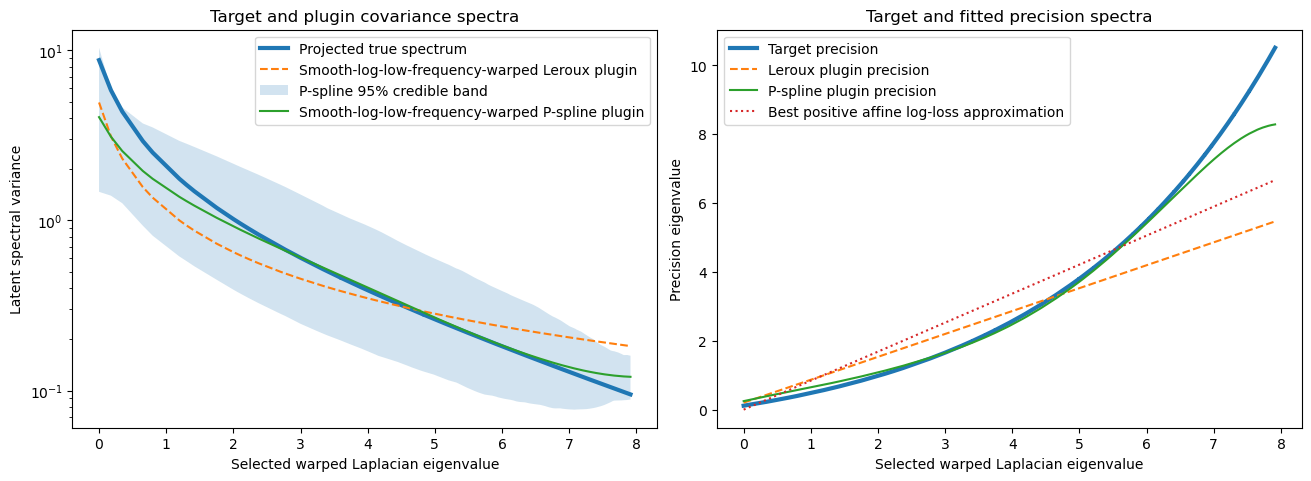

In [72]:
order_warp = np.argsort(
    lam_warp
)


leroux_precision_warp_plugin = (
    1.0
    / F_warped_leroux_plugin
)

spline_precision_warp_plugin = (
    1.0
    / F_warped_spline_plugin
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.7),
    constrained_layout=True,
)


# ------------------------------------------------------------
# Covariance spectrum
# ------------------------------------------------------------

axes[0].plot(
    lam_warp[order_warp],
    target_spectrum_warp[
        order_warp
    ],
    linewidth=3,
    label="Projected true spectrum",
)

axes[0].plot(
    lam_warp[order_warp],
    F_warped_leroux_plugin[
        order_warp
    ],
    linestyle="--",
    label=(
        f"{WARP_DISPLAY_NAME} "
        "Leroux plugin"
    ),
)

axes[0].fill_between(
    lam_warp[order_warp],
    F_warped_spline_lower[
        order_warp
    ],
    F_warped_spline_upper[
        order_warp
    ],
    alpha=0.2,
    label="P-spline 95% credible band",
)

axes[0].plot(
    lam_warp[order_warp],
    F_warped_spline_plugin[
        order_warp
    ],
    label=(
        f"{WARP_DISPLAY_NAME} "
        "P-spline plugin"
    ),
)

axes[0].set_yscale(
    "log"
)

axes[0].set_xlabel(
    "Selected warped Laplacian eigenvalue"
)

axes[0].set_ylabel(
    "Latent spectral variance"
)

axes[0].set_title(
    "Target and plugin covariance spectra"
)

axes[0].legend()


# ------------------------------------------------------------
# Precision spectrum
# ------------------------------------------------------------

axes[1].plot(
    lam_warp[order_warp],
    target_precision_warp[
        order_warp
    ],
    linewidth=3,
    label="Target precision",
)

axes[1].plot(
    lam_warp[order_warp],
    leroux_precision_warp_plugin[
        order_warp
    ],
    linestyle="--",
    label="Leroux plugin precision",
)

axes[1].plot(
    lam_warp[order_warp],
    spline_precision_warp_plugin[
        order_warp
    ],
    label="P-spline plugin precision",
)

axes[1].plot(
    lam_warp[order_warp],
    q_best_affine[
        order_warp
    ],
    linestyle=":",
    label=(
        "Best positive affine "
        "log-loss approximation"
    ),
)

axes[1].set_xlabel(
    "Selected warped Laplacian eigenvalue"
)

axes[1].set_ylabel(
    "Precision eigenvalue"
)

axes[1].set_title(
    "Target and fitted precision spectra"
)

axes[1].legend()

plt.show()

## 13. Numerical spectral comparison

In [73]:
def log_spectrum_rmse(
    estimated,
    target,
    mask=None,
):
    estimated = np.asarray(
        estimated,
        dtype=float,
    )

    target = np.asarray(
        target,
        dtype=float,
    )

    if mask is not None:
        estimated = estimated[
            mask
        ]

        target = target[
            mask
        ]

    estimated = np.clip(
        estimated,
        1e-12,
        None,
    )

    target = np.clip(
        target,
        1e-12,
        None,
    )

    return float(
        np.sqrt(
            np.mean(
                (
                    np.log(estimated)
                    - np.log(target)
                ) ** 2
            )
        )
    )


def spectrum_result_row(
    model,
    summary,
    estimated,
):
    return {
        "model": model,
        "summary": summary,
        "log_spectrum_rmse_all": (
            log_spectrum_rmse(
                estimated,
                target_spectrum_warp,
            )
        ),
        "log_spectrum_rmse_positive": (
            log_spectrum_rmse(
                estimated,
                target_spectrum_warp,
                positive_warp_mask,
            )
        ),
    }


spectral_results = pd.DataFrame(
    [
        spectrum_result_row(
            model="Best affine benchmark",
            summary="log-loss optimum",
            estimated=F_best_affine,
        ),

        spectrum_result_row(
            model=warped_leroux["label"],
            summary="plugin",
            estimated=(
                F_warped_leroux_plugin
            ),
        ),

        spectrum_result_row(
            model=warped_spline["label"],
            summary="plugin",
            estimated=(
                F_warped_spline_plugin
            ),
        ),

        spectrum_result_row(
            model=warped_leroux["label"],
            summary="posterior mean",
            estimated=(
                F_warped_leroux_mean
            ),
        ),

        spectrum_result_row(
            model=warped_spline["label"],
            summary="posterior mean",
            estimated=(
                F_warped_spline_mean
            ),
        ),
    ]
)


spectral_results = (
    spectral_results
    .sort_values(
        "log_spectrum_rmse_positive"
    )
    .reset_index(
        drop=True
    )
)


display(
    spectral_results
)

,model,summary,log_spectrum_rmse_all,log_spectrum_rmse_positive
0,Smooth-log-low-frequency-warped precision P-sp...,plugin,0.123993,0.113093
1,Smooth-log-low-frequency-warped precision P-sp...,posterior mean,0.139839,0.133582
2,Best affine benchmark,log-loss optimum,0.661928,0.273014
3,Smooth-log-low-frequency-warped Leroux,plugin,0.360330,0.359100
4,Smooth-log-low-frequency-warped Leroux,posterior mean,0.384853,0.384544


Direct fit iteration    1 | log-MSE = 0.16662732
Direct fit iteration  500 | log-MSE = 0.00004090
Direct fit iteration 1000 | log-MSE = 0.00000376
Direct fit iteration 1500 | log-MSE = 0.00000149
Direct fit iteration 2000 | log-MSE = 0.00000092
Direct fit iteration 2500 | log-MSE = 0.00000052
Direct fit iteration 3000 | log-MSE = 0.00000029
Direct fit iteration 3500 | log-MSE = 0.00000016
Direct fit iteration 4000 | log-MSE = 0.00000008
Direct P-spline positive-mode log-spectrum RMSE: 0.00028667100614308854
Direct-fit d2 L2 norm: 0.9069820492282884


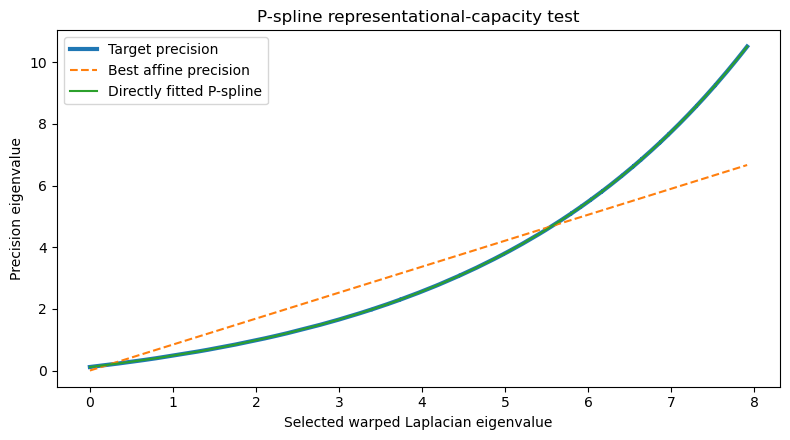

In [74]:
# ============================================================
# Direct representational-capacity test
# ============================================================

direct_filter = (
    make_precision_spline_filter(
        lam_warp_t
    )
)


q_target_t = torch.tensor(
    target_precision_warp,
    dtype=torch.double,
    device=DEVICE,
)

positive_mask_t = torch.tensor(
    positive_warp_mask,
    dtype=torch.bool,
    device=DEVICE,
)


def direct_filter_theta(
    filter_module,
):
    theta = {
        "log_q_left": (
            filter_module
            .mu_log_q_endpoints[0:1]
        ),
        "log_q_right": (
            filter_module
            .mu_log_q_endpoints[1:2]
        ),
    }

    for j in range(
        filter_module.K
    ):
        theta[
            f"d2_{j}_raw"
        ] = (
            filter_module
            .mu_d2[j:j + 1]
        )

    return theta


direct_optimizer = torch.optim.Adam(
    [
        direct_filter
        .mu_log_q_endpoints,

        direct_filter
        .mu_d2,
    ],
    lr=2e-2,
)


DIRECT_ITERS = 4000
direct_loss_history = []


for iteration in range(
    1,
    DIRECT_ITERS + 1,
):
    direct_optimizer.zero_grad(
        set_to_none=True
    )

    theta_direct = (
        direct_filter_theta(
            direct_filter
        )
    )

    q_direct_t = (
        direct_filter
        .precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
    )

    direct_loss = torch.mean(
        (
            torch.log(
                q_direct_t[
                    positive_mask_t
                ]
            )
            - torch.log(
                q_target_t[
                    positive_mask_t
                ]
            )
        ) ** 2
    )

    direct_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            direct_filter
            .mu_log_q_endpoints,

            direct_filter
            .mu_d2,
        ],
        max_norm=10.0,
    )

    direct_optimizer.step()

    direct_loss_history.append(
        float(
            direct_loss.detach().cpu()
        )
    )

    if (
        iteration == 1
        or iteration % 500 == 0
    ):
        print(
            f"Direct fit iteration "
            f"{iteration:4d} | "
            f"log-MSE = "
            f"{direct_loss_history[-1]:.8f}"
        )


with torch.no_grad():
    theta_direct = (
        direct_filter_theta(
            direct_filter
        )
    )

    q_direct_fit = (
        direct_filter
        .precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
        .detach()
        .cpu()
        .numpy()
    )


F_direct_fit = (
    1.0 / q_direct_fit
)


direct_log_spectrum_rmse = (
    log_spectrum_rmse(
        F_direct_fit,
        target_spectrum_warp,
        positive_warp_mask,
    )
)


direct_summary = (
    direct_filter
    .shrinkage_summary()
)


print(
    "Direct P-spline positive-mode "
    "log-spectrum RMSE:",
    direct_log_spectrum_rmse,
)

print(
    "Direct-fit d2 L2 norm:",
    float(
        direct_summary[
            "d2_l2"
        ].cpu()
    ),
)


plt.figure(
    figsize=(8, 4.5)
)

plt.plot(
    lam_warp[order_warp],
    target_precision_warp[
        order_warp
    ],
    linewidth=3,
    label="Target precision",
)

plt.plot(
    lam_warp[order_warp],
    q_best_affine[
        order_warp
    ],
    linestyle="--",
    label="Best affine precision",
)

plt.plot(
    lam_warp[order_warp],
    q_direct_fit[
        order_warp
    ],
    label="Directly fitted P-spline",
)

plt.xlabel(
    "Selected warped Laplacian eigenvalue"
)

plt.ylabel(
    "Precision eigenvalue"
)

plt.title(
    "P-spline representational-capacity test"
)

plt.legend()
plt.tight_layout()
plt.show()

## 14. Precision P-spline curvature

Correct-W d2 L2 norm: 0.25271643564730867
Selected-warp d2 L2 norm: 0.44839798910766515
Selected-warp maximum absolute d2: 0.27460848552426903
Maximum positive-mode log correction: 0.7452236184600767


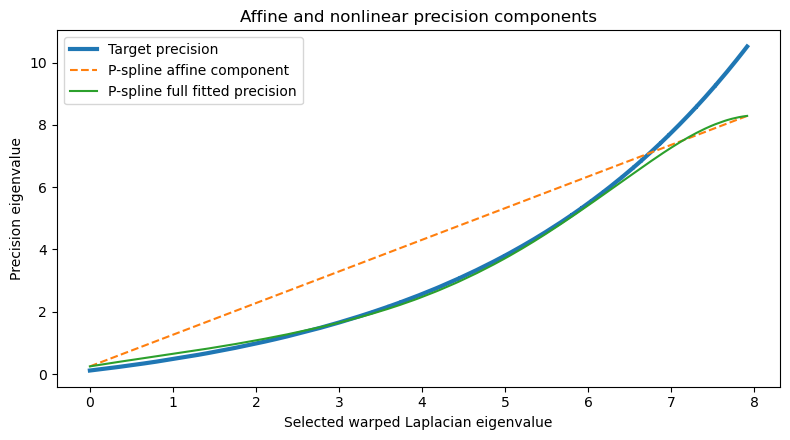

In [75]:
@torch.no_grad()
def precision_spline_diagnostics(result):
    model = result["model"]
    theta_mean = (
        model.filter
        .mean_unconstrained()
    )

    q_full = (
        model.filter
        .precision_from_unconstrained(
            result["lam_t"],
            theta_mean,
        )
        .cpu()
        .numpy()
    )

    q_affine = (
        model.filter
        .affine_precision_from_unconstrained(
            result["lam_t"],
            theta_mean,
        )
        .cpu()
        .numpy()
    )

    correction = (
        model.filter
        .correction_from_unconstrained(
            result["lam_t"],
            theta_mean,
        )
        .cpu()
        .numpy()
    )

    return (
        q_full,
        q_affine,
        correction,
    )


q_warp_full, q_warp_affine, warp_correction = (
    precision_spline_diagnostics(
        warped_spline
    )
)

correct_summary = (
    correct_spline["model"]
    .filter
    .shrinkage_summary()
)

warp_summary = (
    warped_spline["model"]
    .filter
    .shrinkage_summary()
)

print(
    "Correct-W d2 L2 norm:",
    float(
        correct_summary[
            "d2_l2"
        ].cpu()
    ),
)
print(
    "Selected-warp d2 L2 norm:",
    float(
        warp_summary[
            "d2_l2"
        ].cpu()
    ),
)
print(
    "Selected-warp maximum absolute d2:",
    float(
        warp_summary[
            "max_abs_d2"
        ].cpu()
    ),
)
print(
    "Maximum positive-mode log correction:",
    float(
        np.max(
            np.abs(
                warp_correction[
                    positive_mode_mask
                ]
            )
        )
    ),
)

plt.figure(figsize=(8, 4.5))

plt.plot(
    lam_warp[order_warp],
    target_precision_warp[
        order_warp
    ],
    linewidth=3,
    label="Target precision",
)
plt.plot(
    lam_warp[order_warp],
    q_warp_affine[order_warp],
    linestyle="--",
    label="P-spline affine component",
)
plt.plot(
    lam_warp[order_warp],
    q_warp_full[order_warp],
    label="P-spline full fitted precision",
)

plt.xlabel(
    "Selected warped Laplacian eigenvalue"
)
plt.ylabel(
    "Precision eigenvalue"
)
plt.title(
    "Affine and nonlinear precision components"
)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Holdout reconstruction maps

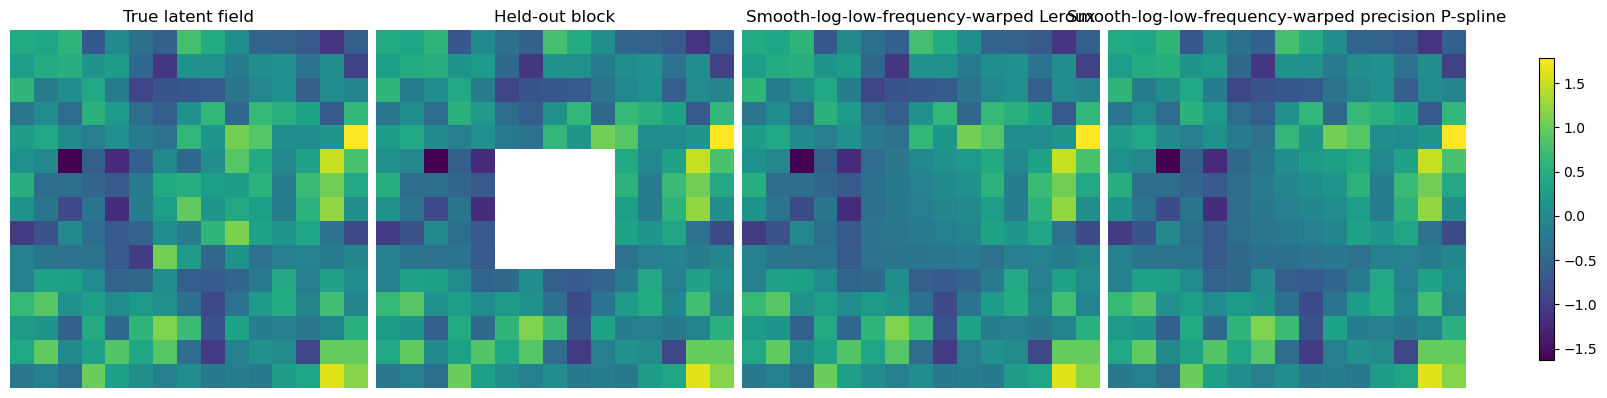

In [76]:
def filled_map(result):
    field = eta_true.copy()

    field[test_mask] = (
        result["prediction"]["mean"]
        .detach()
        .cpu()
        .numpy()
    )

    return field.reshape(
        N_ROWS,
        N_COLS,
    )


masked = eta_true.copy()
masked[test_mask] = np.nan

fields = [
    eta_true.reshape(
        N_ROWS,
        N_COLS,
    ),
    masked.reshape(
        N_ROWS,
        N_COLS,
    ),
    filled_map(warped_leroux),
    filled_map(warped_spline),
]

titles = [
    "True latent field",
    "Held-out block",
    f"{WARP_DISPLAY_NAME} Leroux",
    (
        f"{WARP_DISPLAY_NAME} "
        f"precision P-spline"
    ),
]

finite_values = np.concatenate(
    [
        field[np.isfinite(field)]
        for field in fields
    ]
)

vmin = finite_values.min()
vmax = finite_values.max()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, field, title in zip(
    axes,
    fields,
    titles,
):
    image = ax.imshow(
        field,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
)

plt.show()

## 16. Optimization diagnostics

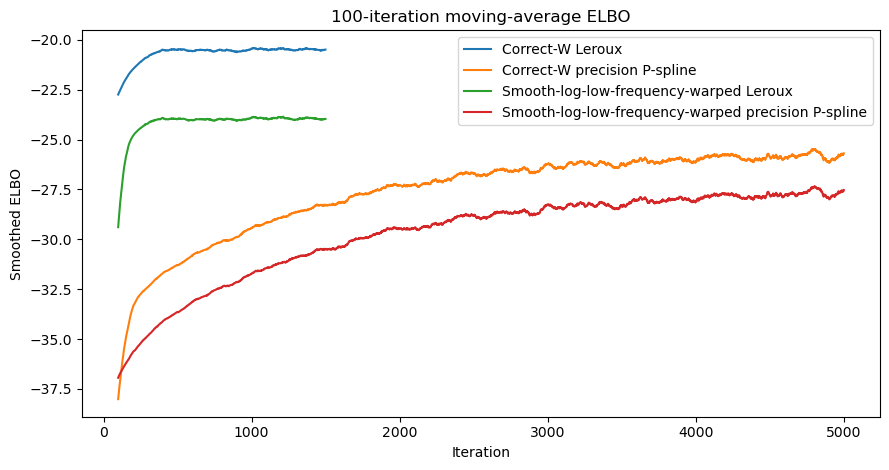

In [77]:
def plot_elbo_histories(
    results,
    window=100,
):
    plt.figure(figsize=(9, 4.8))

    for result in results:
        history = np.asarray(
            result["history"]
        )

        smoothed = (
            pd.Series(history)
            .rolling(window)
            .mean()
        )

        plt.plot(
            smoothed,
            label=result["label"],
        )

    plt.xlabel("Iteration")
    plt.ylabel("Smoothed ELBO")
    plt.title(
        f"{window}-iteration moving-average ELBO"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_elbo_histories(all_fits)

## Interpretation

Both transformations preserve the eigenvectors, so the commutator and off-diagonal covariance ratios should remain close to zero. Any failure is therefore caused by the precision restriction as a function of the supplied warped eigenvalues, rather than by an incorrect spatial basis.

### Smooth quadratic warp

$$
\mu
=
\lambda
+
\delta\frac{\lambda^2}{\lambda_{\max}}.
$$

Its distortion grows toward middle and high frequencies. A useful severity ladder is

$$
\delta
\in
\{0,\;0.25,\;0.50,\;1.00,\;2.00\}.
$$

### Low-frequency power warp

$$
\mu
=
\lambda_{\max}
\left(
\frac{\lambda}{\lambda_{\max}}
\right)^\gamma.
$$

For $\gamma<1$, the distortion is strongest among the smallest positive eigenvalues. A useful severity ladder is

$$
\gamma
\in
\{1.00,\;0.80,\;0.65,\;0.50,\;0.40\}.
$$

For either selected warp, check:

1. the commutator and off-diagonal covariance ratios are approximately zero;
2. the best affine benchmark has nonzero spectral error;
3. the precision P-spline has lower log-spectrum RMSE than Leroux;
4. the P-spline learns a larger second-difference correction when nonlinear adjustment is required;
5. ideally, the correction also improves held-out latent-field RMSE.

A single seed is only a mechanism check. The final study should use paired seeds and fixed severity levels for each warp family.